## Homework 2: Stochastic Gradient Descent

### Exercise 1: SGD vs GD on a Simple 1D Regression Problem

In [31]:
import numpy as np
import matplotlib.pyplot as plt

In [32]:
N = 200
np.random.seed(0)

i = np.arange(1, N + 1)
X = i / N
eps = np.random.normal(0.0, 0.1, size=N)
Y = 2 * X + 1 + eps

batch_sizes = [1, 10, 50, N]

tolL = 1e-6
toltheta = 1e-9

In [33]:
def L(theta, X, Y):
    theta = np.asarray(theta, dtype=float)
    return np.mean((theta[0] + theta[1] * X - Y) ** 2)

def grad_L(theta, X, Y):
    theta = np.asarray(theta, dtype=float)
    r = theta[0] + theta[1] * X - Y
    g0 = np.mean(2.0 * r)
    g1 = np.mean(2.0 * r * X)
    return np.array([g0, g1], dtype=float)

def gradient_descent(L, grad_L, X, Y, theta_0, eta=0.1, maxit=1000, tolL=1e-6, toltheta=1e-9):
    theta = np.asarray(theta_0, dtype=float).copy()

    thetas = [theta.copy()]
    losses = [L(theta, X, Y)]

    for k in range(maxit):
        g = grad_L(theta, X, Y)

        # stopping 1: gradient norm small
        if np.linalg.norm(g) < tolL:
            break

        theta_next = theta - eta * g

        # stopping 2: step size small
        if np.linalg.norm(theta_next - theta) < toltheta:
            theta = theta_next
            thetas.append(theta.copy())
            losses.append(L(theta, X, Y))
            break

        theta = theta_next
        thetas.append(theta.copy())
        losses.append(L(theta, X, Y))

    return theta, k, thetas, losses

def stochastic_gradient_descent(L, grad_L, X, Y, theta_0, eta=0.05, batch_size=10, epochs=100):
    theta = np.asarray(theta_0, dtype=float).copy()
    N = len(X)

    thetas = [theta.copy()]
    losses = [L(theta, X, Y)]

    for epoch in range(epochs):
        idx = np.random.permutation(N)

        for start in range(0, N, batch_size):
            batch_idx = idx[start:start + batch_size]
            g = grad_L(theta, X[batch_idx], Y[batch_idx])
            theta = theta - eta * g
            thetas.append(theta.copy())

        # loss once per epoch
        losses.append(L(theta, X, Y))

    return theta, epoch, thetas, losses

In [34]:
def mse_levelsets(axis, X, Y, xlim=(0, 2), ylim=(0, 2), ngrid=400, ncontours=25):
    t0 = np.linspace(xlim[0], xlim[1], ngrid)
    t1 = np.linspace(ylim[0], ylim[1], ngrid)
    Theta0, Theta1 = np.meshgrid(t0, t1)

    # Broadcast against data
    T0_3d = Theta0[:, :, np.newaxis]      # (ngrid, ngrid, 1)
    T1_3d = Theta1[:, :, np.newaxis]      # (ngrid, ngrid, 1)

    preds = T0_3d + T1_3d * X[np.newaxis, np.newaxis, :]   # (ngrid, ngrid, N)
    Z = np.mean((preds - Y[np.newaxis, np.newaxis, :]) ** 2, axis=2)

    cs = axis.contour(Theta0, Theta1, Z, levels=ncontours)
    axis.clabel(cs, inline=True, fontsize=8)
    axis.axhline(0, lw=0.5, color='k')
    axis.axvline(0, lw=0.5, color='k')
    axis.set_aspect('equal', 'box')
    axis.set_xlabel(r'$\theta_0$')
    axis.set_ylabel(r'$\theta_1$')
    axis.grid(alpha=0.2)
    axis.set_xlim(xlim)
    axis.set_ylim(ylim)
       
    
def plot_GD(eta=0.1, theta_0=(0, 0), maxit=1000, tolL=1e-6, toltheta=1e-9,
            xlim=(0, 2), ylim=(0, 2), ncontours=25):

    sol_theta, it, thetas, losses = gradient_descent(
        L, grad_L, X, Y, theta_0, eta=eta, maxit=maxit, tolL=tolL, toltheta=toltheta
    )

    fig, axs = plt.subplots(1, 2)
    fig.set_figheight(7)
    fig.set_figwidth(16)
    fig.suptitle("Gradient Descent", fontsize=20)

    mse_levelsets(axs[0], X, Y, xlim=xlim, ylim=ylim, ncontours=ncontours)

    c1 = np.array([0.7, 0.7, 1.0])  # light blue
    c2 = np.array([0.0, 0.0, 0.8])  # darker blue
    colors = [c1 + (c2 - c1) * t for t in np.linspace(0, 1, len(thetas))]

    thetas = np.array(thetas)
    axs[0].plot(thetas[:, 0], thetas[:, 1], linewidth=0.75, zorder=1)
    axs[0].scatter(thetas[:, 0], thetas[:, 1], c=colors, s=15, zorder=2, label="successive thetas")
    axs[0].scatter(sol_theta[0], sol_theta[1], c="red", s=25, zorder=3,
                   label=f"final theta at ({sol_theta[0]:.2f}, {sol_theta[1]:.2f})")
    axs[0].legend()

    axs[1].plot(losses)
    axs[1].set_title("Loss values vs Iteration")
    axs[1].set_xlabel("Iteration")
    axs[1].set_ylabel("Loss value")
    axs[1].grid(alpha=0.2)

    print("Iterations:", it)
    plt.tight_layout()
    plt.show()
    
    
def plot_SGD(eta=0.05, theta_0=(0, 0), epochs=100, batch_sizes=(1, 10, 50, 200),
             xlim=(0, 2), ylim=(0, 2), ncontours=25):

    fig, axs = plt.subplots(len(batch_sizes), 2)
    fig.set_figheight(5 * len(batch_sizes))
    fig.set_figwidth(16)
    fig.suptitle("Stochastic Gradient Descent (Mini-batch)", fontsize=20)

    c1 = np.array([0.7, 0.7, 1.0])
    c2 = np.array([0.0, 0.0, 0.8])

    for i, bs in enumerate(batch_sizes):
        sol_theta, epoch, thetas, losses = stochastic_gradient_descent(
            L, grad_L, X, Y, theta_0, eta=eta, batch_size=bs, epochs=epochs
        )

        mse_levelsets(axs[i][0], X, Y, xlim=xlim, ylim=ylim, ncontours=ncontours)
        thetas = np.array(thetas)

        colors = [c1 + (c2 - c1) * t for t in np.linspace(0, 1, len(thetas))]
        axs[i][0].set_title(fr"$N_{{batch}} = {bs}$")
        axs[i][0].plot(thetas[:, 0], thetas[:, 1], linewidth=0.75, zorder=1)
        axs[i][0].scatter(thetas[:, 0], thetas[:, 1], c=colors, s=12, zorder=2, label="successive thetas")
        axs[i][0].scatter(sol_theta[0], sol_theta[1], c="red", s=25, zorder=3,
                          label=f"final theta at ({sol_theta[0]:.2f}, {sol_theta[1]:.2f})")
        axs[i][0].legend()

        axs[i][1].plot(losses)
        axs[i][1].set_title("Loss values vs Epochs")
        axs[i][1].set_xlabel("Epoch")
        axs[i][1].set_ylabel("Loss value")
        axs[i][1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

Iterations: 199


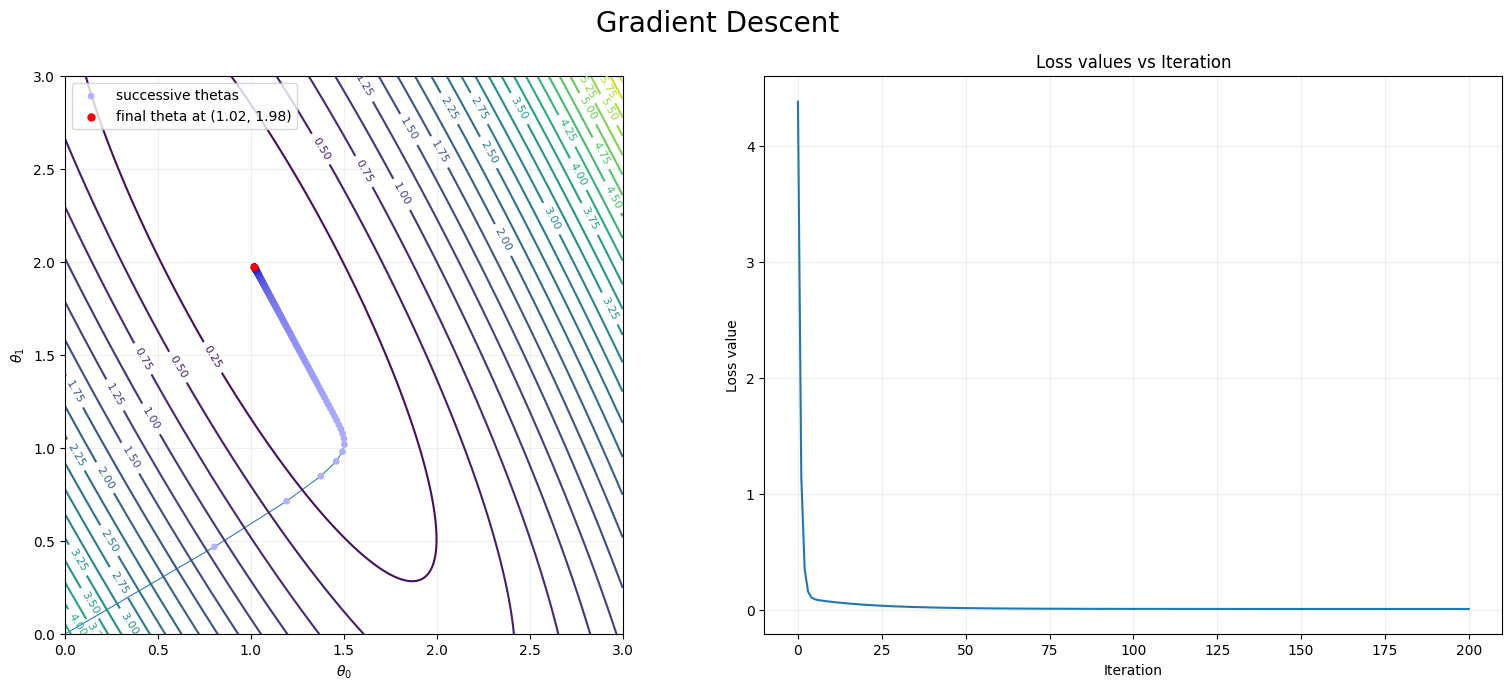

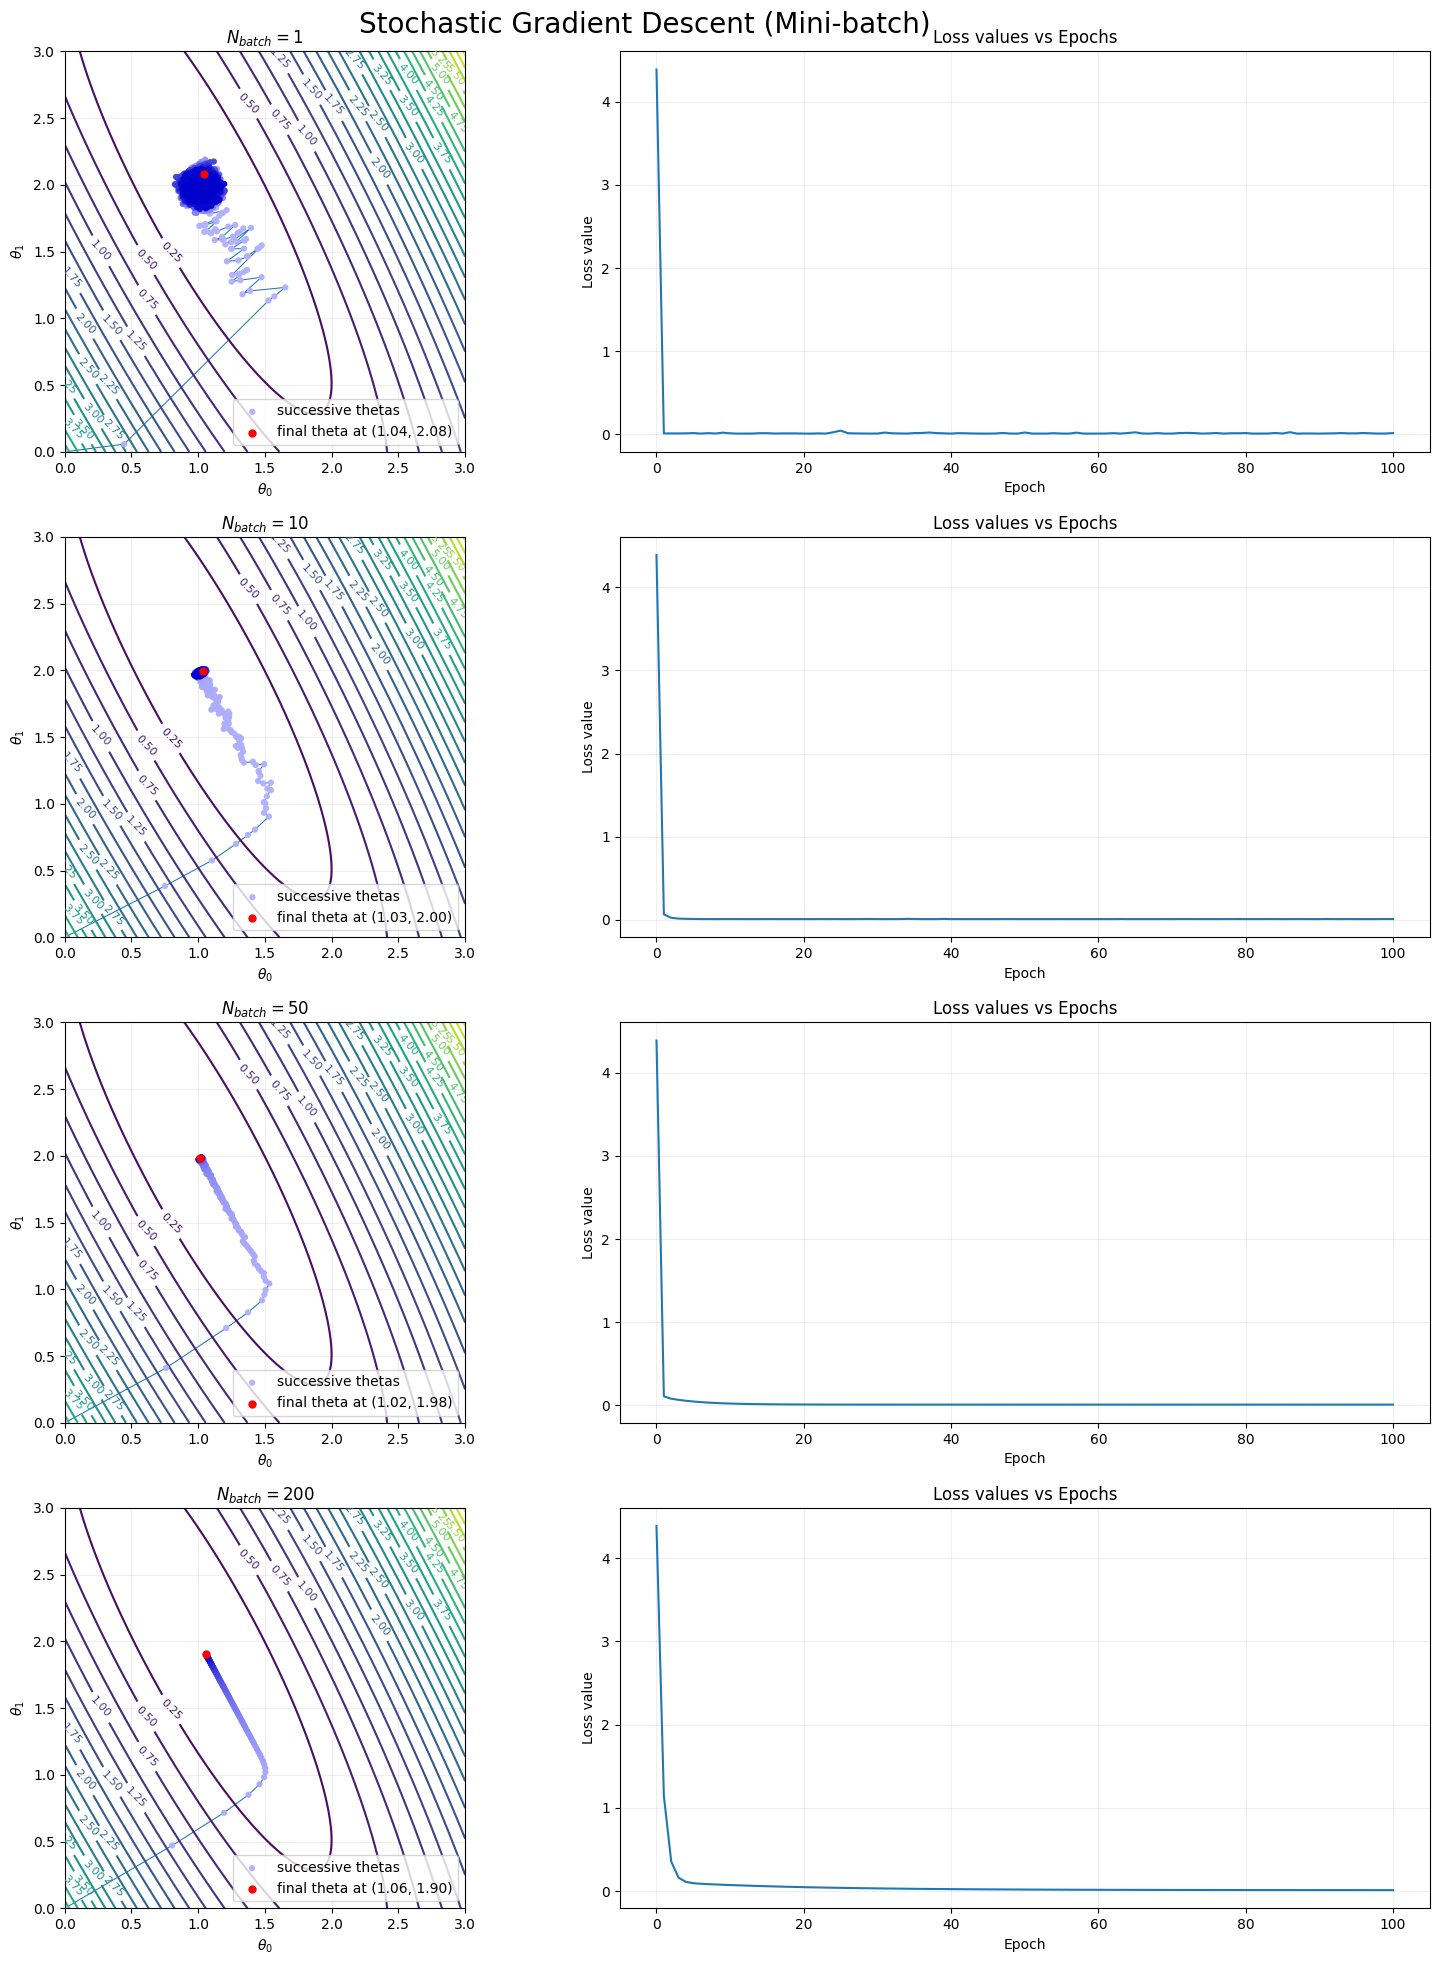

In [35]:
xlim = (0, 3)
ylim = (0, 3)

plot_GD(eta=0.2, theta_0=(0, 0), maxit=200, tolL=tolL, toltheta=toltheta, xlim=xlim, ylim=ylim, ncontours=25)

plot_SGD(eta=0.2, theta_0=(0, 0), epochs=100, batch_sizes=batch_sizes, xlim=xlim, ylim=ylim, ncontours=25)